# EDA & Feature Engineering — 
Goal: understand the reactor yield behavior and engineer physics-informed features 
for the ML model, based on the A -> B -> C reaction network.

In [61]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

train = pd.read_csv('../data/raw/train_dataset.csv')
test = pd.read_csv('../data/raw/test_dataset.csv')

train.head()

,flow_rate_L_min,concentration_mol_L,inlet_temperature_K,length_m,jacket_temperature_K,overall_yield
0,33.09,3.68,357.75,19.87,383.79,63.024
1,76.30,1.34,429.70,14.84,405.72,86.611
2,59.90,1.01,431.10,11.76,385.40,86.347
3,49.90,2.21,445.61,22.85,367.74,92.175
4,16.70,3.95,458.91,4.56,374.13,82.211


In [62]:
print("Train shape:", train.shape)
print("Test shape:", test.shape)
train.info()

Train shape: (150, 6)
Test shape: (50, 5)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 6 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   flow_rate_L_min       150 non-null    float64
 1   concentration_mol_L   150 non-null    float64
 2   inlet_temperature_K   150 non-null    float64
 3   length_m              150 non-null    float64
 4   jacket_temperature_K  150 non-null    float64
 5   overall_yield         150 non-null    float64
dtypes: float64(6)
memory usage: 7.2 KB


In [63]:
train.describe()

,flow_rate_L_min,concentration_mol_L,inlet_temperature_K,length_m,jacket_temperature_K,overall_yield
count,150.000000,150.000000,150.000000,150.000000,150.000000,150.000000
mean,40.466800,2.311333,424.423400,14.086533,442.240800,36.222173
std,22.239772,1.019844,45.200641,6.995343,55.047768,38.427427
min,5.410000,0.520000,351.630000,2.260000,354.010000,0.000000
25%,21.112500,1.362500,387.255000,8.027500,393.327500,0.013500
50%,38.610000,2.445000,425.630000,14.235000,437.080000,15.314000
75%,61.227500,3.155000,462.972500,20.685000,486.180000,74.876500
max,79.020000,3.970000,498.580000,24.990000,547.990000,99.971000


In [64]:
print("Train shape:", train.shape)
print("Test shape:", test.shape)
train.info()

Train shape: (150, 6)
Test shape: (50, 5)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 6 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   flow_rate_L_min       150 non-null    float64
 1   concentration_mol_L   150 non-null    float64
 2   inlet_temperature_K   150 non-null    float64
 3   length_m              150 non-null    float64
 4   jacket_temperature_K  150 non-null    float64
 5   overall_yield         150 non-null    float64
dtypes: float64(6)
memory usage: 7.2 KB


## Key Finding: Bimodal Yield Distribution
~38% of training rows have yield near 0%, while a smaller cluster sits near 90-100%.
This suggests a threshold/cutoff behavior rather than a smooth relationship — the reactor
either "succeeds" or "fails" based on operating conditions, likely driven by overheating
pushing the reaction past B into unwanted byproduct C.

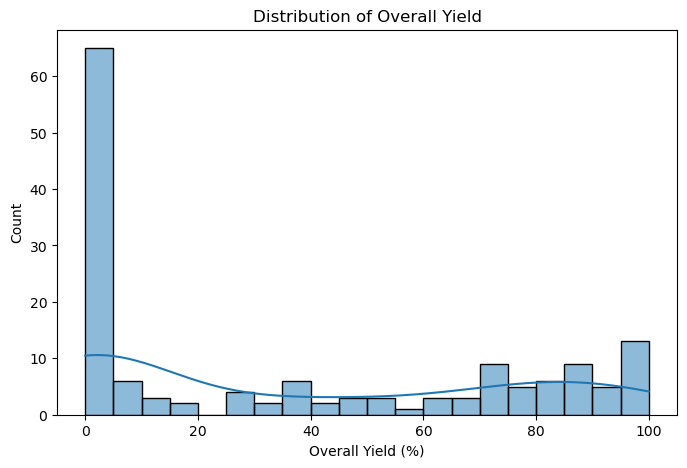

In [65]:
plt.figure(figsize=(8,5))
sns.histplot(train['overall_yield'], bins=20, kde=True)
plt.title('Distribution of Overall Yield')
plt.xlabel('Overall Yield (%)')
plt.show()

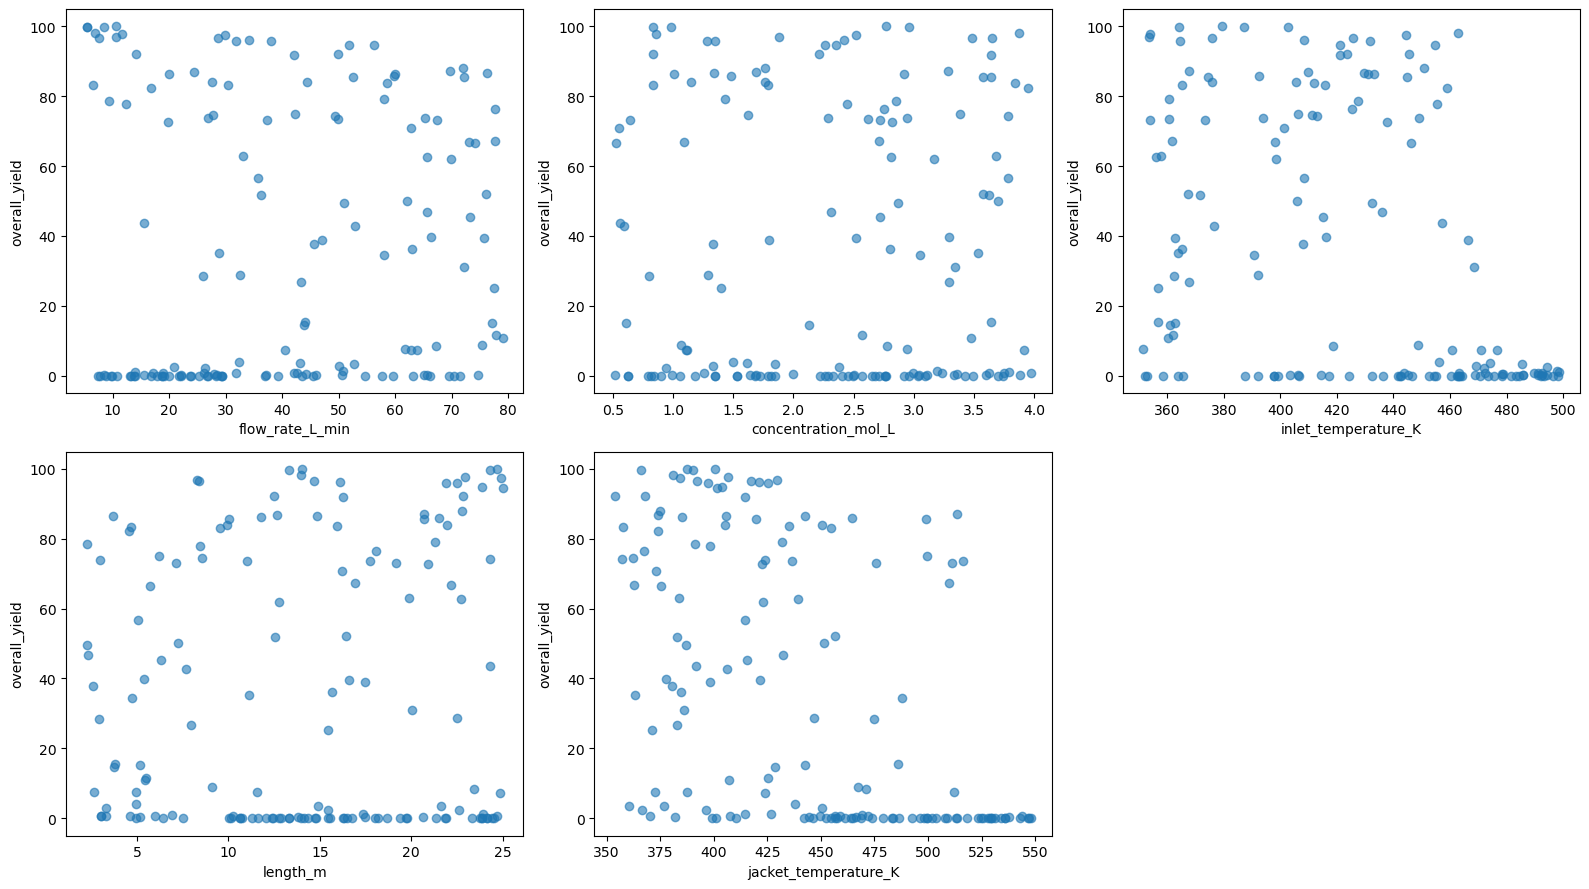

In [66]:
fig, axes = plt.subplots(2, 3, figsize=(16, 9))
features = ['flow_rate_L_min', 'concentration_mol_L', 'inlet_temperature_K', 'length_m', 'jacket_temperature_K']

for i, feature in enumerate(features):
    ax = axes[i // 3, i % 3]
    ax.scatter(train[feature], train['overall_yield'], alpha=0.6)
    ax.set_xlabel(feature)
    ax.set_ylabel('overall_yield')

axes[1, 2].axis('off')
plt.tight_layout()
plt.show()

In [67]:
train['delta_T'] = train['jacket_temperature_K'] - train['inlet_temperature_K']
train['avg_temp'] = (train['jacket_temperature_K'] + train['inlet_temperature_K']) / 2

train[['delta_T', 'avg_temp', 'overall_yield']].corr()['overall_yield']

delta_T         -0.129203
avg_temp        -0.636739
overall_yield    1.000000
Name: overall_yield, dtype: float64

In [68]:
train['residence_time'] = train['length_m'] / train['flow_rate_L_min']

train[['residence_time', 'overall_yield']].corr()['overall_yield']

residence_time    0.076424
overall_yield     1.000000
Name: overall_yield, dtype: float64

In [69]:
train['heat_exposure'] = train['residence_time'] * train['avg_temp']

train[['heat_exposure', 'overall_yield']].corr()['overall_yield']

heat_exposure    0.00331
overall_yield    1.00000
Name: overall_yield, dtype: float64

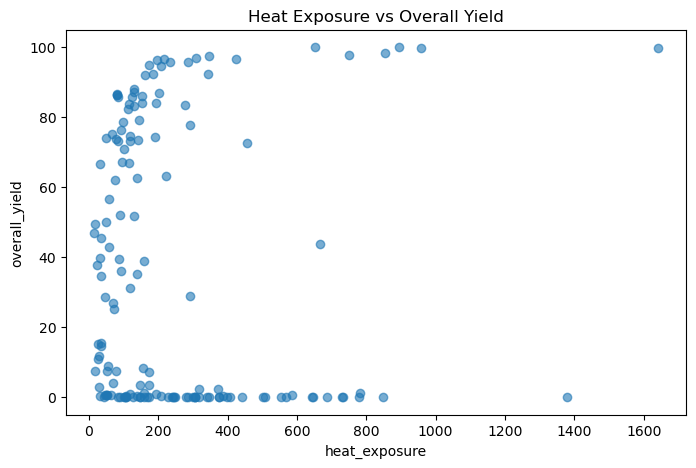

In [70]:
plt.figure(figsize=(8,5))
plt.scatter(train['heat_exposure'], train['overall_yield'], alpha=0.6)
plt.xlabel('heat_exposure')
plt.ylabel('overall_yield')
plt.title('Heat Exposure vs Overall Yield')
plt.show()

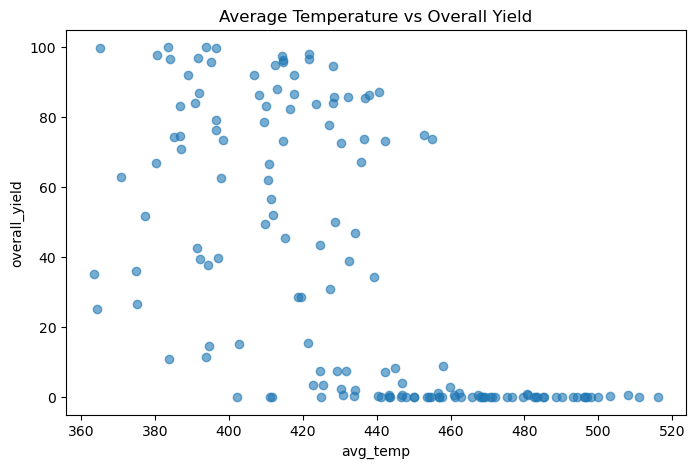

In [71]:
plt.figure(figsize=(8,5))
plt.scatter(train['avg_temp'], train['overall_yield'], alpha=0.6)
plt.xlabel('avg_temp')
plt.ylabel('overall_yield')
plt.title('Average Temperature vs Overall Yield')
plt.show()

In [72]:
low_temp = train[train['avg_temp'] < 420]
print("Rows in low-temp subgroup:", low_temp.shape[0])

low_temp[['flow_rate_L_min', 'concentration_mol_L', 'residence_time', 'overall_yield']].corr()['overall_yield']

Rows in low-temp subgroup: 58


flow_rate_L_min       -0.282051
concentration_mol_L   -0.146130
residence_time         0.301580
overall_yield          1.000000
Name: overall_yield, dtype: float64

In [73]:
train['is_high_temp'] = (train['avg_temp'] > 430).astype(int)
train['temp_residence_interaction'] = train['residence_time'] * (430 - train['avg_temp'])

train[['is_high_temp', 'temp_residence_interaction', 'overall_yield']].corr()['overall_yield']

is_high_temp                 -0.626467
temp_residence_interaction    0.507167
overall_yield                 1.000000
Name: overall_yield, dtype: float64

In [74]:
test['avg_temp'] = (test['jacket_temperature_K'] + test['inlet_temperature_K']) / 2
test['residence_time'] = test['length_m'] / test['flow_rate_L_min']
test['is_high_temp'] = (test['avg_temp'] > 430).astype(int)
test['temp_residence_interaction'] = test['residence_time'] * (430 - test['avg_temp'])

test.head()

,flow_rate_L_min,concentration_mol_L,inlet_temperature_K,length_m,jacket_temperature_K,avg_temp,residence_time,is_high_temp,temp_residence_interaction
0,43.73,2.88,454.18,7.66,440.61,447.395,0.175166,1,-3.047009
1,47.80,2.33,401.37,19.95,390.13,395.750,0.417364,0,14.294718
2,7.14,0.65,411.86,3.05,476.23,444.045,0.427171,1,-5.999615
3,17.86,1.28,385.97,22.36,353.56,369.765,1.251960,0,75.411792
4,56.40,2.51,495.33,8.36,517.71,506.520,0.148227,1,-11.342326


In [75]:
train.to_csv('../data/processed/train_features.csv', index=False)
test.to_csv('../data/processed/test_features.csv', index=False)

print("Saved successfully")

Saved successfully


## Feature Engineering Summary
Two-stage physics story discovered:
1. **Temperature decides if the reaction can succeed at all** — above ~430K average 
   temperature, yield reliably crashes to near-zero (likely over-conversion to byproduct C).
2. **Given a safe temperature, residence time decides how far the reaction progresses** — 
   within the low-temp subgroup, residence_time correlation improves from 0.08 to 0.30.

`temp_residence_interaction` captures both effects in a single feature and is the 
strongest engineered predictor found (0.507 correlation).

In [76]:
feature_summary = pd.DataFrame({
    'feature': ['avg_temp', 'delta_T', 'residence_time', 'heat_exposure', 'is_high_temp', 'temp_residence_interaction'],
    'correlation_with_yield': [-0.637, -0.129, 0.076, 0.003, -0.626, 0.507],
    'kept': ['Yes', 'No', 'Yes', 'No', 'Yes', 'Yes'],
    'notes': [
        'Strongest raw signal; shows clear cliff ~430K',
        'Weak; overall heat level matters more than the gap',
        'Weak alone, but 0.30 within safe-temp subgroup',
        'Diluted signal from combining with weak residence_time',
        'Binary flag for the temperature cliff',
        'Best combined feature; captures two-stage physics story'
    ]
})
feature_summary

,feature,correlation_with_yield,kept,notes
0,avg_temp,-0.637,Yes,Strongest raw signal; shows clear cliff ~430K
1,delta_T,-0.129,No,Weak; overall heat level matters more than the...
2,residence_time,0.076,Yes,"Weak alone, but 0.30 within safe-temp subgroup"
3,heat_exposure,0.003,No,Diluted signal from combining with weak reside...
4,is_high_temp,-0.626,Yes,Binary flag for the temperature cliff
5,temp_residence_interaction,0.507,Yes,Best combined feature; captures two-stage phys...
